In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
edge = np.linspace(-1, 1, 300)
upper_y = np.cos(np.pi * edge / 2)
lower_y = edge**4
upper_x = 1/(np.e**-1 - np.e) * (np.exp(edge)-np.e)
lower_x = 0.5 * (edge**2-edge)
xv, yv = np.meshgrid(edge, edge)

In [3]:
def compute_potential(potential, n_iter):
    length = len(potential[0])
    for n in range(n_iter):
        for i in range(1, length-1):
            for j in range(1, length-1):
                potential[j][i] = 1/4 * (potential[j+1][i] + potential[j-1][i] + potential[j][i+1] + potential[j][i-1])
    return potential

In [4]:
potential = np.zeros((300,300))
potential[0,:]= lower_y
potential[-1,:]= upper_y
potential[:,0]= lower_x
potential[:,-1]= upper_x
potential = compute_potential(potential, n_iter=100)

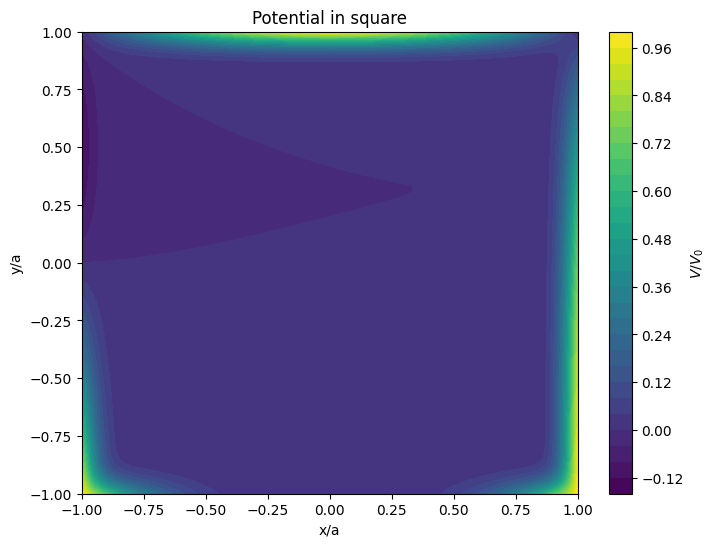

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
clr_plot = ax.contourf(xv, yv, potential, 30)
ax.set_xlabel('x/a')
ax.set_ylabel('y/a')
fig.colorbar(clr_plot, label='$V/V_0$')
ax.set_title('Potential in square')
plt.show()

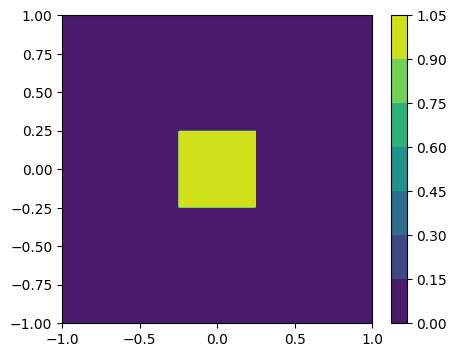

In [6]:
def potential_block(x, y):
    return np.select([(x>-0.25)*(x<0.25)*(y>-0.25)*(y<0.25),
                      (x<=-0.25)+(x>=0.25)+(y<=-0.25)+(y>=0.25)],
                     [1.,
                      0])
plt.figure(figsize=(5,4))
plt.contourf(xv, yv, potential_block(xv,yv))
plt.colorbar()
fixed = potential_block(xv,yv)
fixed_bool = fixed!=0

In [7]:
def compute_potential(potential, fixed_bool, n_iter):
    length = len(potential[0])
    for n in range(n_iter):
        for i in range(1, length-1):
            for j in range(1, length-1):
                if not(fixed_bool[j][i]):
                    potential[j][i] = 1/4 * (potential[j+1][i] + potential[j-1][i] + potential[j][i+1] + potential[j][i-1])
    return potential

In [8]:
potential = np.zeros((300,300))
potential[0,:]= lower_y
potential[-1,:]= upper_y
potential[:,0]= lower_x
potential[:,-1]= upper_x
potential[fixed_bool] = fixed[fixed_bool]
potential = compute_potential(potential, fixed_bool, n_iter=100)

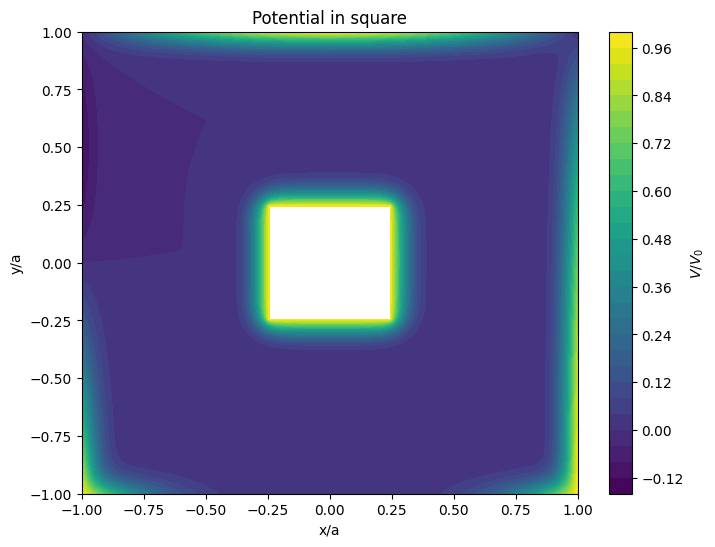

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
clr_plot = ax.contourf(xv, yv, potential, 30)
ax.set_xlabel('x/a')
ax.set_ylabel('y/a')
fig.colorbar(clr_plot, label='$V/V_0$')
ax.set_title('Potential in square')
plt.show()

In [14]:
# Van der Pauw corner voltage simulation
n = 3000
contact_size = 10
V_plus = 10.0
V_minus = -10.0

potential_vdp = np.zeros((n, n))
fixed_vdp = np.zeros((n, n), dtype=bool)

# Top-left contact at +V, bottom-left contact at -V (same side)
potential_vdp[:contact_size, :contact_size] = V_plus
potential_vdp[-contact_size:, :contact_size] = V_minus
fixed_vdp[:contact_size, :contact_size] = True
fixed_vdp[-contact_size:, :contact_size] = True

# Relax the solution while preserving corner contacts
potential_vdp = compute_potential(potential_vdp, fixed_vdp, n_iter=100)

# Plot the potential distribution
fig, ax = plt.subplots(figsize=(7, 6))
contours = ax.contourf(xv, yv, potential_vdp, 40, cmap='seismic')
ax.set_xlabel('x/a')
ax.set_ylabel('y/a')
ax.set_title('Van der Pauw: +V top-left and -V bottom-left')
fig.colorbar(contours, label='$V/V_0$')
plt.show()

KeyboardInterrupt: 